# Task 9 — Spam Detector (TF-IDF + SVM)

**Goal:** classify SMS messages as **spam** or **ham** (legitimate) with a **TF-IDF vectorizer + linear SVM**.

Dataset: SMS Spam Collection (5,574 messages, UCI) — `data/sms_spam.tsv` (tab-separated: label, text).

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, precision_score, recall_score, f1_score)

RANDOM_STATE = 42
os.makedirs("outputs", exist_ok=True); os.makedirs("model", exist_ok=True)
sns.set_theme(style="whitegrid")

## 1. Load and inspect

In [2]:
df = pd.read_csv("data/sms_spam.tsv", sep="\t", header=None, names=["label", "text"])
print("rows:", len(df), "| duplicate texts:", df["text"].duplicated().sum())
df["label"].value_counts()

rows: 5572 | duplicate texts: 403


label
ham     4825
spam     747
Name: count, dtype: int64

The classes are **imbalanced** (~13% spam), so plain accuracy would be misleading (always guessing "ham" gives 87%).
We will report **precision, recall and F1 for the spam class**.

The data also contains many **exact duplicate messages**. If the same text lands in both train and test, the score
is inflated, so we drop duplicates *before* splitting.

(5169, 4) {'ham': 0.874, 'spam': 0.126}


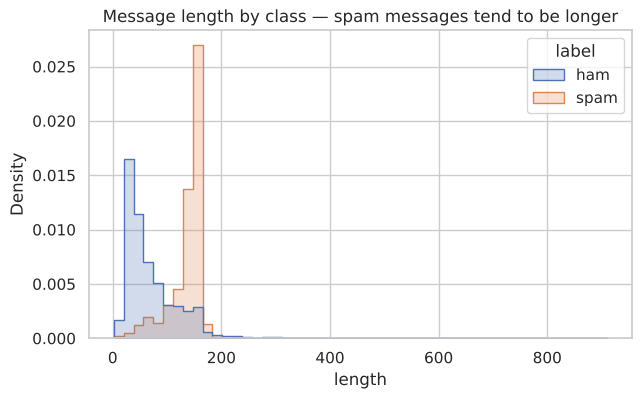

In [3]:
df = df.drop_duplicates(subset="text").reset_index(drop=True)
df["y"] = (df["label"] == "spam").astype(int)
df["length"] = df["text"].str.len()
print(df.shape, df["label"].value_counts(normalize=True).round(3).to_dict())

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="length", hue="label", bins=50, element="step", stat="density", common_norm=False)
plt.title("Message length by class — spam messages tend to be longer")
plt.savefig("outputs/length_distribution.png", dpi=120, bbox_inches="tight"); plt.show()

## 2. Train / test split (stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["y"], test_size=0.2, stratify=df["y"], random_state=RANDOM_STATE
)
print(len(X_train), "train /", len(X_test), "test  | spam share:", round(y_train.mean(), 3), round(y_test.mean(), 3))

4135 train / 1034 test  | spam share: 0.126 0.127


## 3. TF-IDF + Linear SVM pipeline

- **TF-IDF** turns each message into a vector: words that are frequent in a message but rare overall (like "free", "claim", "prize") get high weights.
- We use **unigrams + bigrams**, lowercase text, English stop-words removed, and `sublinear_tf` to damp very frequent words.
- **LinearSVC** finds the maximum-margin hyperplane between spam and ham. It is fast and works very well on sparse high-dimensional text.
- `class_weight="balanced"` makes mistakes on the rare spam class cost more.

In [5]:
pipe = Pipeline([
    ("tfidf", TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1, 2),
                              min_df=2, sublinear_tf=True)),
    ("svm", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE)),
])

# 5-fold cross-validation on the training data only (F1 of the spam class)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
print("CV F1 per fold:", cv_f1.round(3), "| mean:", cv_f1.mean().round(4))

pipe.fit(X_train, y_train)

CV F1 per fold: [0.931 0.93  0.95  0.904 0.905] | mean: 0.924


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",2
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a se

## 4. Evaluation on the held-out test set

In [6]:
pred = pipe.predict(X_test)
print(classification_report(y_test, pred, target_names=["ham", "spam"], digits=3))

metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "spam_precision": precision_score(y_test, pred),
    "spam_recall": recall_score(y_test, pred),
    "spam_f1": f1_score(y_test, pred),
}
print({k: round(v, 4) for k, v in metrics.items()})

              precision    recall  f1-score   support

         ham      0.986     0.991     0.988       903
        spam      0.937     0.901     0.918       131

    accuracy                          0.980      1034
   macro avg      0.961     0.946     0.953      1034
weighted avg      0.979     0.980     0.980      1034

{'accuracy': 0.9797, 'spam_precision': 0.9365, 'spam_recall': 0.9008, 'spam_f1': 0.9183}


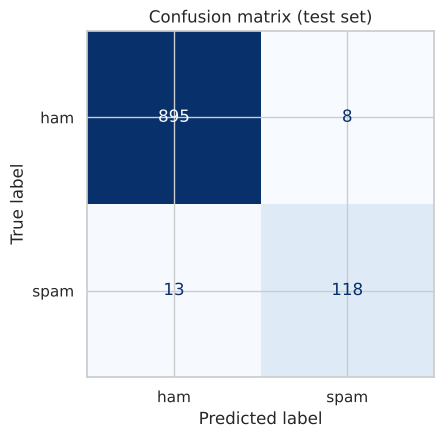

In [7]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["ham", "spam"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test set)")
plt.savefig("outputs/confusion_matrix.png", dpi=120, bbox_inches="tight"); plt.show()

**How to read it:** *false positives* (ham flagged as spam) are the costly mistake for a real inbox, so precision matters;
*false negatives* are spam that slips through. Both are listed below so we can see what the model gets wrong.

In [8]:
errors = pd.DataFrame({"text": X_test.values, "actual": y_test.values, "predicted": pred})
errors = errors[errors.actual != errors.predicted]
errors["error"] = np.where(errors.predicted == 1, "false positive (ham → spam)", "false negative (spam missed)")
pd.set_option("display.max_colwidth", 140)
errors[["error", "text"]].head(10)

,error,text
29,false positive (ham → spam),Your daily text from me – a favour this time
95,false negative (spam missed),Want explicit SEX in 30 secs? Ring 02073162414 now! Costs 20p/min Gsex POBOX 2667 WC1N 3XX
105,false negative (spam missed),You will recieve your tone within the next 24hrs. For Terms and conditions please see Channel U Teletext Pg 750
168,false negative (spam missed),Hi if ur lookin 4 saucy daytime fun wiv busty married woman Am free all next week Chat now 2 sort time 09099726429 JANINExx Calls£1/minM...
230,false negative (spam missed),ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS...
293,false positive (ham → spam),Are you free now?can i call now?
301,false positive (ham → spam),"Please protect yourself from e-threats. SIB never asks for sensitive information like Passwords,ATM/SMS PIN thru email. Never share your..."
308,false negative (spam missed),Hi its LUCY Hubby at meetins all day Fri & I will B alone at hotel U fancy cumin over? Pls leave msg 2day 09099726395 Lucy x Calls£1/min...
326,false negative (spam missed),Missed call alert. These numbers called but left no message. 07008009200
327,false positive (ham → spam),K k:) sms chat with me.


## 5. What did the model learn? Top spam / ham words

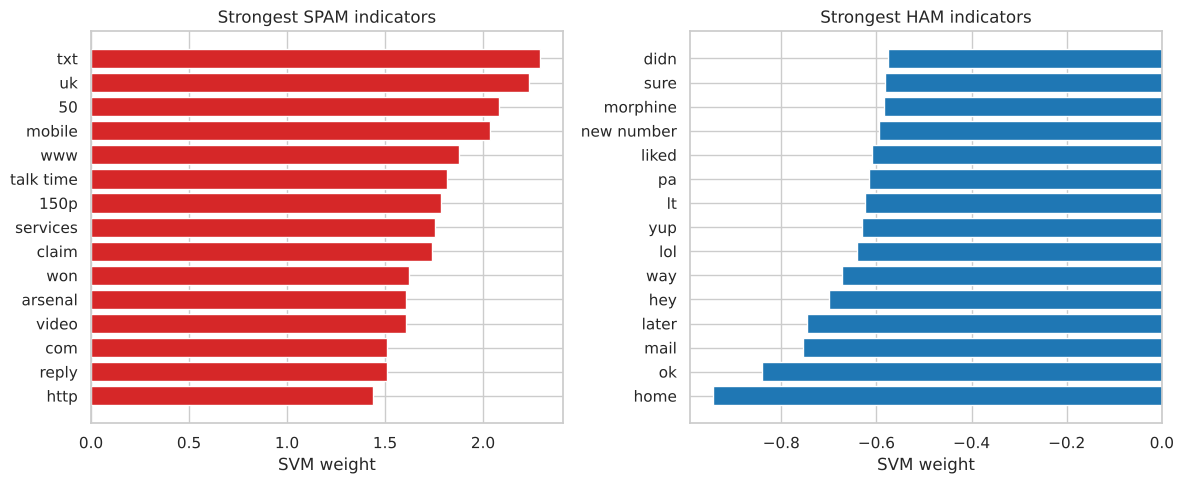

Spam: ['txt', 'uk', '50', 'mobile', 'www', 'talk time', '150p', 'services', 'claim', 'won', 'arsenal', 'video', 'com', 'reply', 'http']
Ham:  ['didn', 'sure', 'morphine', 'new number', 'liked', 'pa', 'lt', 'yup', 'lol', 'way', 'hey', 'later', 'mail', 'ok', 'home']


In [9]:
vec, svm = pipe.named_steps["tfidf"], pipe.named_steps["svm"]
names = np.array(vec.get_feature_names_out())
order = np.argsort(svm.coef_[0])
top_ham, top_spam = names[order[:15]][::-1], names[order[-15:]][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, idx, title, color in [(axes[0], order[-15:], "Strongest SPAM indicators", "#d62728"),
                              (axes[1], order[:15], "Strongest HAM indicators", "#1f77b4")]:
    ax.barh(names[idx], svm.coef_[0][idx], color=color); ax.set_title(title); ax.set_xlabel("SVM weight")
plt.tight_layout(); plt.savefig("outputs/top_features.png", dpi=120); plt.show()
print("Spam:", list(top_spam)); print("Ham: ", list(top_ham))

## 6. Sample predictions on brand-new messages

In [10]:
samples = [
    "WINNER!! You have been selected to receive a £900 prize reward. Call 09061701461 now to claim.",
    "Hey, are we still meeting for lunch at 1pm today?",
    "Congratulations! Free entry to win a brand new iPhone. Text WIN to 80082 now",
    "Can you send me the notes from yesterday's lecture? I missed the last 20 minutes",
    "URGENT! Your account has been suspended. Click http://bit.ly/verify to claim your free gift",
    "Mom said dinner will be ready by 8, don't be late",
    "You have won a 1000 cash prize! To claim call 08712300220 before it expires",
    "I'll call you after the class, my phone battery is dying",
]
scores = pipe.decision_function(samples)
out = pd.DataFrame({"message": samples, "prediction": np.where(scores > 0, "SPAM", "ham"), "svm_score": scores.round(2)})
out

,message,prediction,svm_score
0,WINNER!! You have been selected to receive a £900 prize reward. Call 09061701461 now to claim.,SPAM,0.91
1,"Hey, are we still meeting for lunch at 1pm today?",ham,-1.59
2,Congratulations! Free entry to win a brand new iPhone. Text WIN to 80082 now,SPAM,0.94
3,Can you send me the notes from yesterday's lecture? I missed the last 20 minutes,ham,-0.66
4,URGENT! Your account has been suspended. Click http://bit.ly/verify to claim your free gift,SPAM,1.00
5,"Mom said dinner will be ready by 8, don't be late",ham,-1.33
6,You have won a 1000 cash prize! To claim call 08712300220 before it expires,SPAM,1.42
7,"I'll call you after the class, my phone battery is dying",ham,-1.27


A positive SVM score means spam; the larger the magnitude, the further from the decision boundary (more confident).

In [11]:
joblib.dump(pipe, "model/spam_tfidf_svm.joblib")
out.to_csv("outputs/sample_predictions.csv", index=False)
pd.Series(metrics).round(4).to_csv("outputs/test_metrics.csv", header=["value"])

# reload check + a tiny reusable helper
loaded = joblib.load("model/spam_tfidf_svm.joblib")
def is_spam(text: str) -> bool:
    return bool(loaded.predict([text])[0])
print(is_spam("Free entry!! Text WIN to claim your prize"), is_spam("see you at 6 then"))

True False


## Summary
- **TF-IDF (1–2 grams) + LinearSVC** with class weighting, evaluated on a de-duplicated, stratified hold-out set.
- Results are in the metrics above; the model is saved to `model/spam_tfidf_svm.joblib` and `predict.py` provides a command-line demo.
- Limitations: trained on short English SMS from ~2012; it won't generalise as-is to modern email phishing or other languages.